# dodawanie bibliotek

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.feature_selection import RFECV
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib
import os


# Dodanie i przetwarzanie danych

In [2]:
df_unscaled = pd.read_csv('dane.csv')

In [3]:
df_numeric = df_unscaled.select_dtypes(include="number")

In [4]:
scaler = MinMaxScaler()
df = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

In [5]:
df['klasyfikator'] = df['song_popularity'].apply(lambda x: 0 if x < 0.70 else 1)

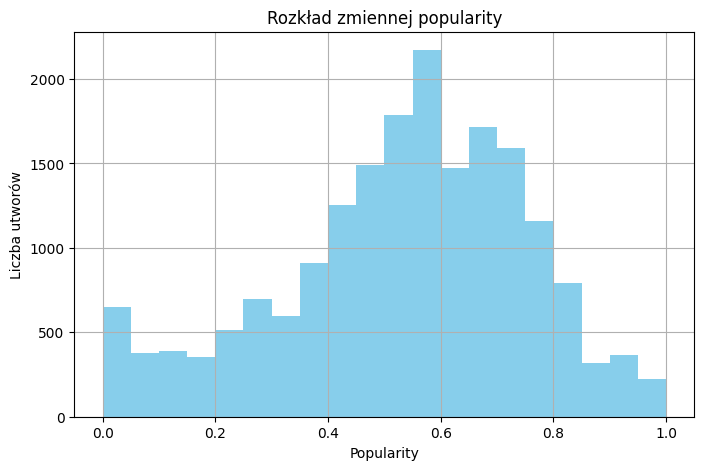

In [6]:
df['song_popularity'].hist(bins=20, figsize=(8,5), color='skyblue')
plt.xlabel('Popularity')
plt.ylabel('Liczba utworów')
plt.title('Rozkład zmiennej popularity')
plt.show()

In [7]:
df_r = df

In [8]:
df_r = df_r.drop(columns=['klasyfikator'])

In [9]:
df = df.drop(columns=['song_popularity'])

<Axes: ylabel='klasyfikator'>

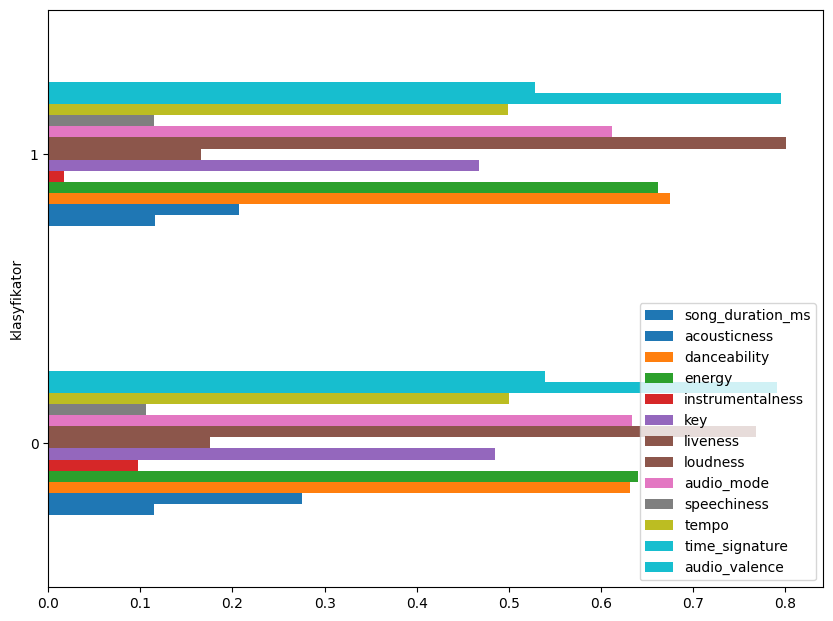

In [10]:
(
    df.groupby("klasyfikator")
      .mean(numeric_only=True)      # 👈 dodaj ten argument!
      .plot.barh(cmap="tab10", figsize=(10, 7.5))
)

# korelacje

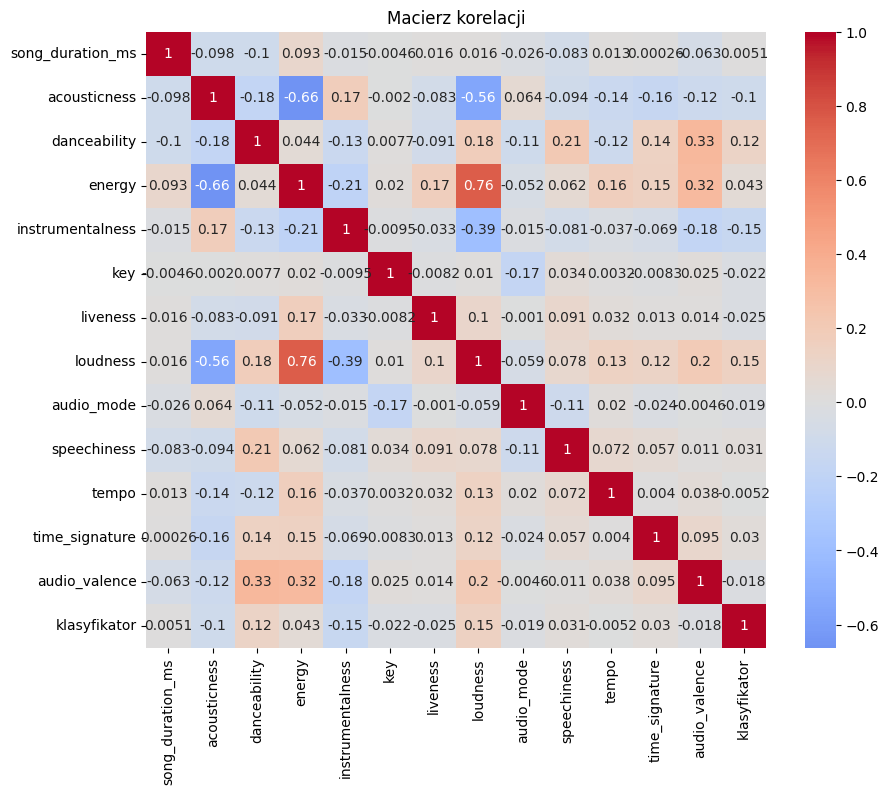

In [11]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Macierz korelacji')
plt.show()

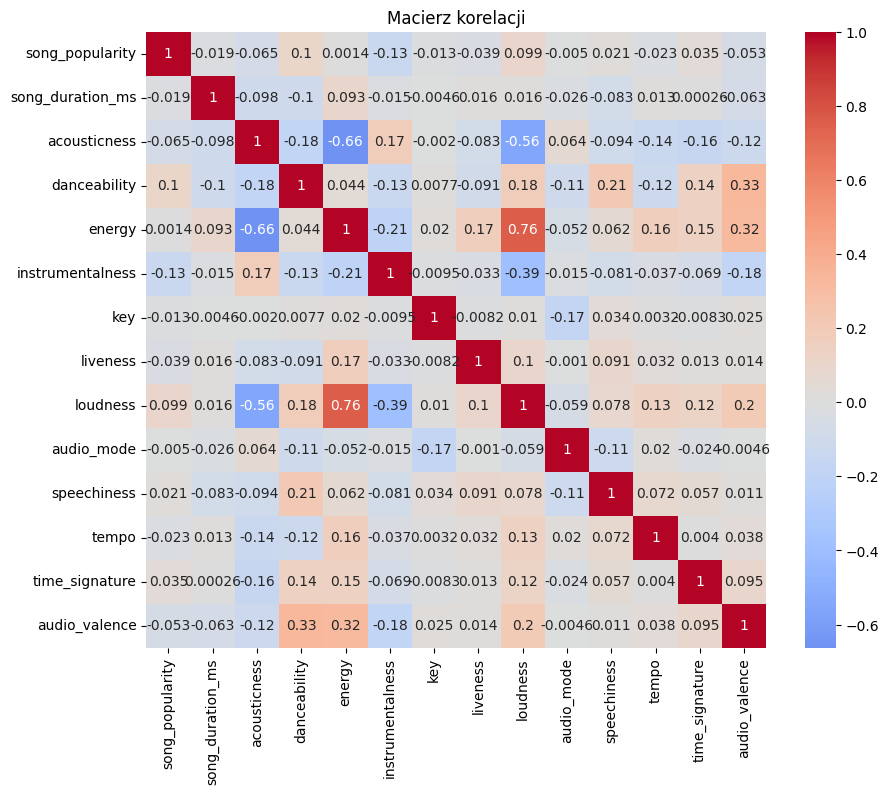

In [13]:
corr_matrix = df_r.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Macierz korelacji')
plt.show()

# Modele

## KNN

### regresja

In [14]:
target_column = 'song_popularity'
X = df_r.drop(target_column, axis=1)
y = df_r[target_column]

In [15]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

In [16]:
print(f"Liczba cech oryginalnych: {X.shape[1]}")
print(f"Liczba cech po PCA: {X_pca.shape[1]}")

Liczba cech oryginalnych: 13
Liczba cech po PCA: 8


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [ ]:
k_range = range(1, 50)
rmse_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_scores.append(rmse)

best_k_index = np.argmin(rmse_scores)
best_k = k_range[best_k_index]
min_rmse = rmse_scores[best_k_index]

print(f"\nZnaleziono najlepsze k: {best_k}")
print(f"Błąd RMSE dla tego k: {min_rmse:.2f}")


Znaleziono najlepsze k: 7
Błąd RMSE dla tego k: 0.21


Współczynnik R2 modelu: 0.1052


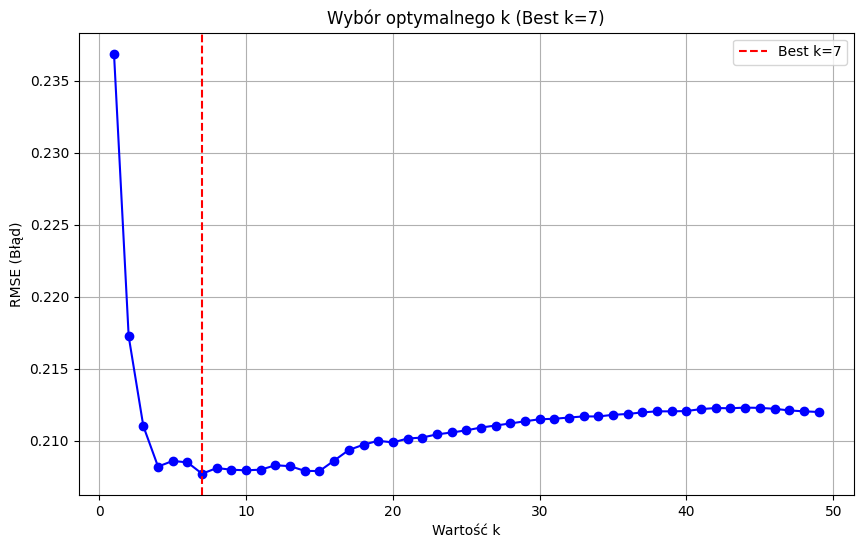

In [ ]:
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)
r2 = r2_score(y_test, final_predictions)
print(f"Współczynnik R2 modelu: {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, rmse_scores, marker='o', linestyle='-', color='blue')
plt.title(f'Wybór optymalnego k (Best k={best_k})')
plt.xlabel('Wartość k')
plt.ylabel('RMSE (Błąd)')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True)
plt.show()

### przewidywanie klasy 0-1

In [20]:
X = df.drop("klasyfikator", axis=1)
y = df["klasyfikator"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Liczba oryginalnych cech: {X_train.shape[1]}")
print(f"Liczba cech po PCA: {X_train_pca.shape[1]}")

Liczba oryginalnych cech: 13
Liczba cech po PCA: 8


In [22]:
k_values = range(1, 26, 2)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', algorithm='kd_tree')
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

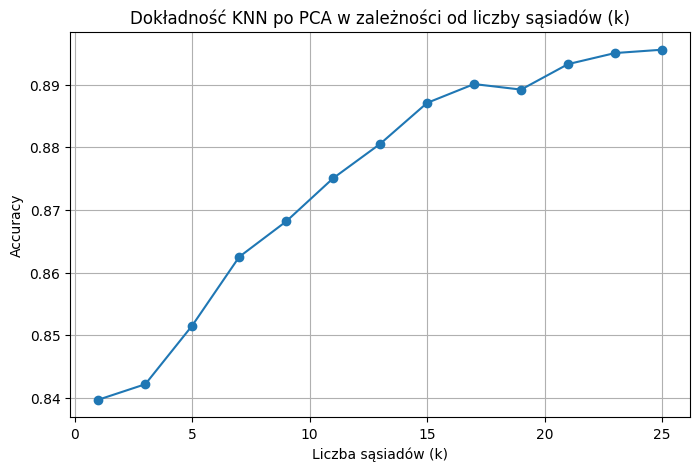

In [23]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Dokładność KNN po PCA w zależności od liczby sąsiadów (k)")
plt.xlabel("Liczba sąsiadów (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [24]:
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Najlepsze k: {best_k} (dokładność = {max(accuracies):.3f})")

Najlepsze k: 25 (dokładność = 0.896)


In [25]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_pca, y_train)

y_pred = knn.predict(X_test_pca)

In [26]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='distance', algorithm='kd_tree')
knn_final.fit(X_train_pca, y_train)
y_pred_final = knn_final.predict(X_test_pca)

In [27]:
print("Dokładność (accuracy):", accuracy_score(y_test, y_pred_final))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_final))

Dokładność (accuracy): 0.8955937002300478

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      4314
           1       0.82      0.72      0.77      1337

    accuracy                           0.90      5651
   macro avg       0.87      0.83      0.85      5651
weighted avg       0.89      0.90      0.89      5651



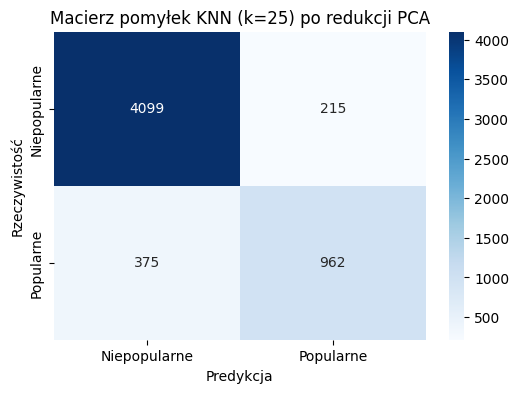

In [28]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Niepopularne", "Popularne"],
            yticklabels=["Niepopularne", "Popularne"])
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title(f"Macierz pomyłek KNN (k={best_k}) po redukcji PCA")
plt.show()

## Random forrest

### regresja

In [12]:
X = df_r.drop('song_popularity', axis=1)
y = df_r['song_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [14]:
print("chwilę to trwa (3m 11s)")
rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-4,
    scoring='neg_mean_squared_log_error'
)

rf_random.fit(X_train, y_train)

chwilę to trwa (3m 11s)
Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'neg_mean_squared_log_error'
,n_jobs,-4
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
best_model = rf_random.best_estimator_

print(f"\nNajlepsze parametry: {rf_random.best_params_}")

predictions = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"RMSE (Średni błąd): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


Najlepsze parametry: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
RMSE (Średni błąd): 0.17
R2 Score: 0.3856


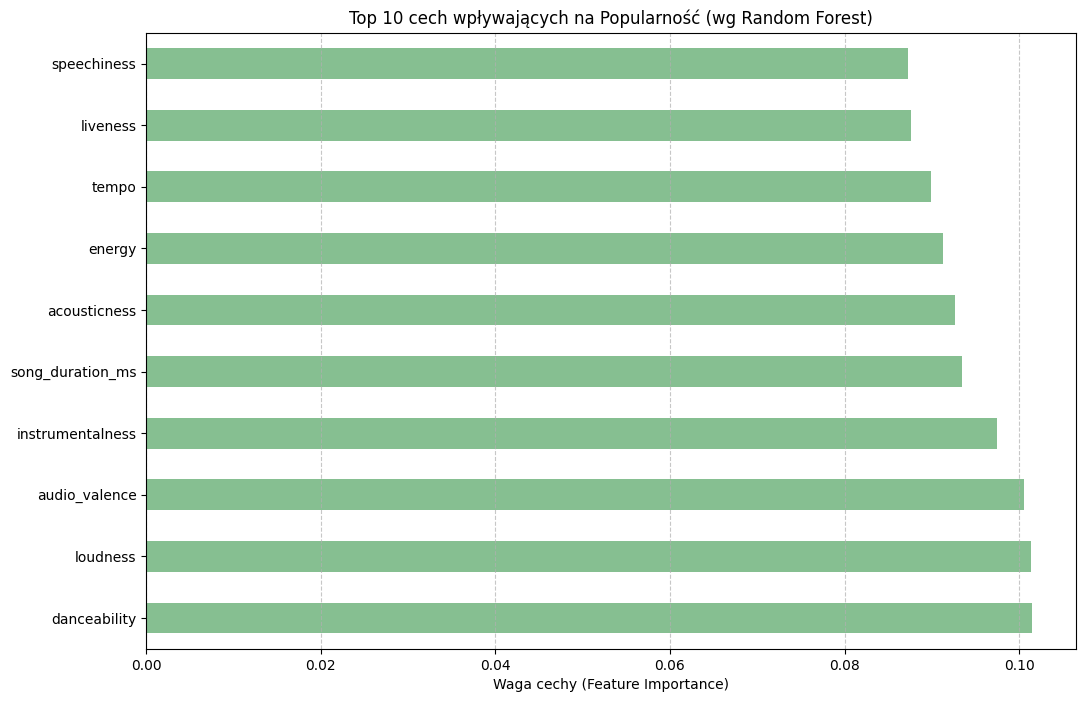

In [16]:
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#86bf91')
plt.title('Top 10 cech wpływających na Popularność (wg Random Forest)')
plt.xlabel('Waga cechy (Feature Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### klasyfikator 0-1

In [17]:
X = df.drop("klasyfikator", axis=1)
y = df["klasyfikator"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}


rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=4,
    scoring='roc_auc'
)

rf_random.fit(X_train, y_train)

Rozpoczynam optymalizację klasyfikatora na i5-8400...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': ['balanced', 'balanced_subsample', ...], 'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], ...}"
,n_iter,15
,scoring,'roc_auc'
,n_jobs,4
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
best_model = rf_random.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"\nNajlepsze parametry: {rf_random.best_params_}")
print(f"Accuracy (Dokładność): {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))


Najlepsze parametry: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
------------------------------
Accuracy (Dokładność): 0.9195
ROC AUC Score: 0.9064
------------------------------

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4314
           1       0.93      0.71      0.81      1337

    accuracy                           0.92      5651
   macro avg       0.92      0.85      0.88      5651
weighted avg       0.92      0.92      0.92      5651



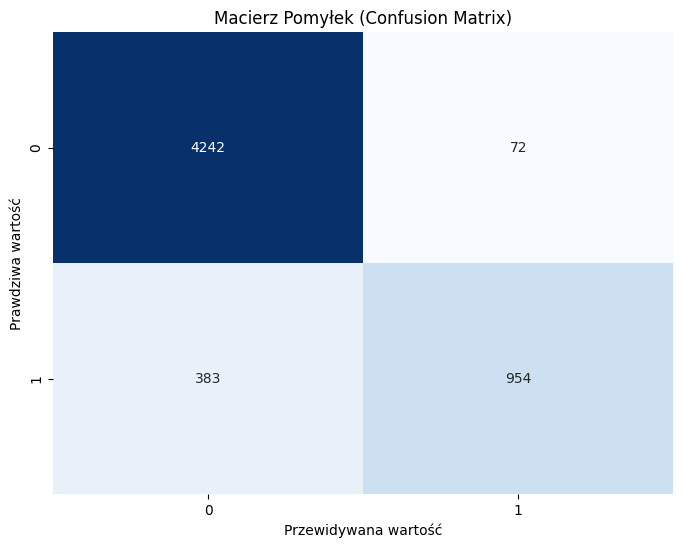

In [37]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.ylabel('Prawdziwa wartość')
plt.xlabel('Przewidywana wartość')
plt.show()

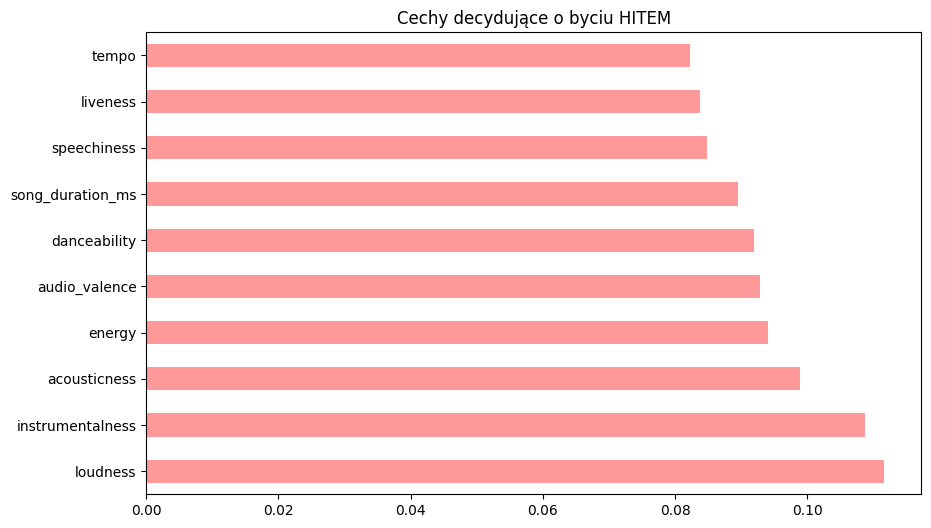

In [38]:
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#ff9999')
plt.title('Cechy decydujące o byciu HITEM')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
y_pred = rf_random.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4314
           1       0.93      0.71      0.81      1337

    accuracy                           0.92      5651
   macro avg       0.92      0.85      0.88      5651
weighted avg       0.92      0.92      0.92      5651



In [21]:
import pandas as pd
best_rf = rf_random.best_estimator_
importances = pd.DataFrame({
    'Cecha': X.columns,
    'Waga': best_rf.feature_importances_
}).sort_values(by='Waga', ascending=False)
print(importances.head(8))

               Cecha      Waga
7           loudness  0.111666
4   instrumentalness  0.108726
1       acousticness  0.098960
3             energy  0.094039
12     audio_valence  0.092806
2       danceability  0.091906
0   song_duration_ms  0.089524
9        speechiness  0.084837


## regresja logistyczna

### regresja

In [39]:
X_r = df_r.drop('song_popularity', axis=1)
y_r = df_r['song_popularity']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(random_state=42)
param_dist_reg = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', None]
}

In [ ]:
search_reg = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=4,
    scoring='neg_mean_squared_error',
    random_state=42
)

search_reg.fit(X_train_r, y_train_r)
best_reg = search_reg.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [41]:
pred_r = best_reg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))
print(f"NAJLEPSZY MODEL REGRESJI: {search_reg.best_params_}")
print(f"RMSE (Średni błąd w pkt): {rmse:.2f}")

NAJLEPSZY MODEL REGRESJI: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
RMSE (Średni błąd w pkt): 0.17


### klasyfikacja 0-1

In [42]:
X_c = df.drop('klasyfikator', axis=1)
y_c = df['klasyfikator']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

In [ ]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_dist_clf = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

search_clf = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=param_dist_clf,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=4,
    scoring='roc_auc',
    random_state=42
)

search_clf.fit(X_train_c, y_train_c)
best_clf = search_clf.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [44]:
pred_c = best_clf.predict(X_test_c)
prob_c = best_clf.predict_proba(X_test_c)[:, 1]
auc = roc_auc_score(y_test_c, prob_c)

print(f"NAJLEPSZY MODEL KLASYFIKACJI: {search_clf.best_params_}")
print(f"ROC AUC Score: {auc:.4f}")

NAJLEPSZY MODEL KLASYFIKACJI: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
ROC AUC Score: 0.9108


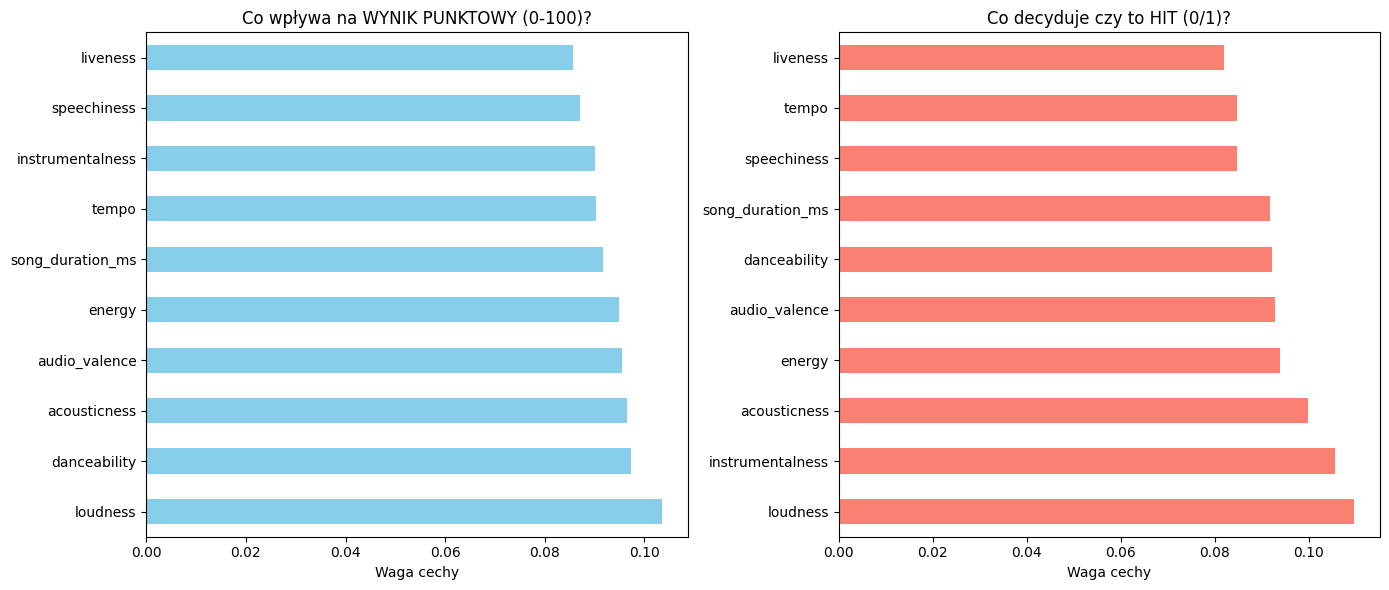

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
feat_imp_r = pd.Series(best_reg.feature_importances_, index=X_r.columns)
feat_imp_r.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Co wpływa na WYNIK PUNKTOWY (0-100)?')
plt.xlabel('Waga cechy')

plt.subplot(1, 2, 2)
feat_imp_c = pd.Series(best_clf.feature_importances_, index=X_c.columns)
feat_imp_c.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Co decyduje czy to HIT (0/1)?')
plt.xlabel('Waga cechy')

plt.tight_layout()
plt.show()

## XGBoost

### regresja

In [ ]:
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

param_dist_reg = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

In [47]:
search_reg = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist_reg,
    n_iter=15,
    cv=3,
    verbose=1,
    n_jobs=4,
    scoring='neg_mean_squared_error',
    random_state=42
)

search_reg.fit(X_train_r, y_train_r)
best_reg = search_reg.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [48]:
pred_r = best_reg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))
print(f"NAJLEPSZE PARAMETRY (REG): {search_reg.best_params_}")
print(f"RMSE: {rmse:.2f}")

NAJLEPSZE PARAMETRY (REG): {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
RMSE: 0.18


### Klasyfikacja 0-1

In [49]:
num_negative = np.sum(y_c == 0)
num_positive = np.sum(y_c == 1)
ratio = float(num_negative) / num_positive

In [50]:
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=4,
    scale_pos_weight=ratio,
    eval_metric='auc',
    random_state=42
)
param_dist_clf = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 6],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 0.1, 0.5]
}

In [51]:
search_clf = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist_clf,
    n_iter=15,
    cv=3,
    verbose=1,
    n_jobs=4,
    scoring='roc_auc',
    random_state=42
)

print("Rozpoczynam trening naprawionego modelu...")
search_clf.fit(X_train_c, y_train_c)

Rozpoczynam trening naprawionego modelu...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,15
,scoring,'roc_auc'
,n_jobs,4
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [52]:
best_clf = search_clf.best_estimator_
prob_c = best_clf.predict_proba(X_test_c)[:, 1]
auc = roc_auc_score(y_test_c, prob_c)

print(f"NAJLEPSZE PARAMETRY (CLF): {search_clf.best_params_}")
print(f"ROC AUC Score: {auc:.4f}")

NAJLEPSZE PARAMETRY (CLF): {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
ROC AUC Score: 0.8867


## MLP siec neuronowa

### regresja

In [ ]:
mlp_reg = MLPRegressor(max_iter=500, random_state=42, early_stopping=True)

param_dist_reg = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

In [54]:
search_reg = RandomizedSearchCV(
    estimator=mlp_reg, 
    param_distributions=param_dist_reg, 
    n_iter=10, 
    cv=3, 
    n_jobs=4, 
    verbose=1,
    scoring='neg_mean_squared_error'
)

search_reg.fit(X_train_r, y_train_r)
best_reg = search_reg.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [55]:
rmse = np.sqrt(mean_squared_error(y_test_r, best_reg.predict(X_test_r)))
print(f"REGRESJA RMSE: {rmse:.2f}")
print(f"Najlepsza architektura: {search_reg.best_params_['hidden_layer_sizes']}")

REGRESJA RMSE: 0.21
Najlepsza architektura: (100,)


### klasyfikacja 0-1

In [56]:
mlp_clf = MLPClassifier(max_iter=500, random_state=42, early_stopping=True)

search_clf = RandomizedSearchCV(
    estimator=mlp_clf, 
    param_distributions=param_dist_reg,
    n_iter=50, 
    cv=3, 
    n_jobs=4, 
    verbose=1,
    scoring='roc_auc'
)

search_clf.fit(X_train_c, y_train_c)
best_clf = search_clf.best_estimator_

Fitting 3 folds for each of 32 candidates, totalling 96 fits


C:\Users\Szymon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [57]:
roc = roc_auc_score(y_test_c, best_clf.predict_proba(X_test_c)[:, 1])
print(f"KLASYFIKACJA ROC AUC: {roc:.4f}")

KLASYFIKACJA ROC AUC: 0.6873


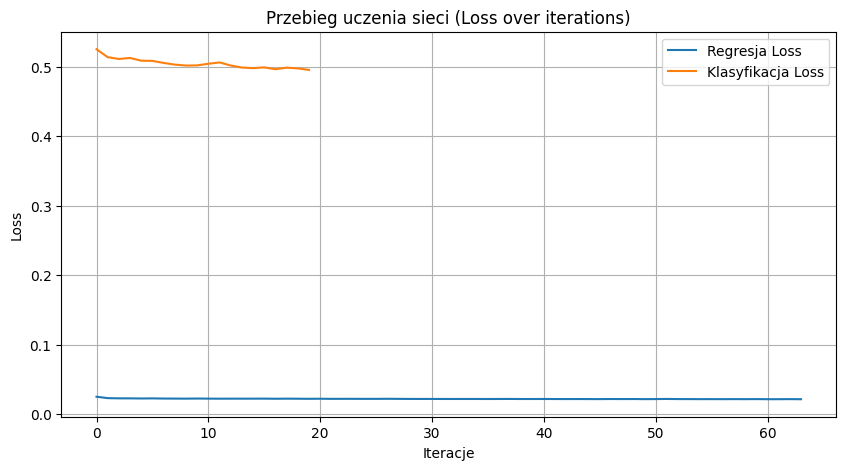

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(best_reg.loss_curve_, label='Regresja Loss')
plt.plot(best_clf.loss_curve_, label='Klasyfikacja Loss')
plt.title('Przebieg uczenia sieci (Loss over iterations)')
plt.xlabel('Iteracje')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# wyniki

In [59]:
results_reg = {}
results_clf = {}
np.random.seed(42)

In [ ]:
#KNN + PCA
pipe_knn = Pipeline([
    ('pca', PCA(n_components=0.95)), 
    ('knn', KNeighborsRegressor(n_neighbors=38))
])
pipe_knn.fit(X_train_r, y_train_r)
rmse_knn = np.sqrt(mean_squared_error(y_test_r, pipe_knn.predict(X_test_r)))
results_reg['KNN + PCA'] = rmse_knn
print(f"KNN + PCA: {rmse_knn:.2f}")

#Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=20, n_jobs=4, random_state=42)
rf.fit(X_train_r, y_train_r)
rmse_rf = np.sqrt(mean_squared_error(y_test_r, rf.predict(X_test_r)))
results_reg['Random Forest'] = rmse_rf
print(f"Random Forest: {rmse_rf:.2f}")

#XGBoost
xgbr = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, tree_method='hist', n_jobs=4, random_state=42)
xgbr.fit(X_train_r, y_train_r)
rmse_xgb = np.sqrt(mean_squared_error(y_test_r, xgbr.predict(X_test_r)))
results_reg['XGBoost'] = rmse_xgb
print(f"XGBoost: {rmse_xgb:.2f}")

#Sieć Neuronowa (MLP)
mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42)
mlp_reg.fit(X_train_r, y_train_r)
rmse_mlp = np.sqrt(mean_squared_error(y_test_r, mlp_reg.predict(X_test_r)))
results_reg['Neural Network (MLP)'] = rmse_mlp
print(f"Neural Network: {rmse_mlp:.2f}")

KNN + PCA: 0.21
Random Forest: 0.17
XGBoost: 0.19
Neural Network: 0.21


In [ ]:
#Regresja Logistyczna
log_reg = LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.5, class_weight='balanced', max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)
auc_log = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
results_clf['Logistic Reg (ElasticNet)'] = auc_log
print(f"Logistic Regression: {auc_log:.4f}")

#Random Forest
rf_c = RandomForestClassifier(n_estimators=300, max_depth=20, class_weight='balanced', n_jobs=4, random_state=42)
rf_c.fit(X_train, y_train)
auc_rf = roc_auc_score(y_test, rf_c.predict_proba(X_test)[:, 1])
results_clf['Random Forest'] = auc_rf
print(f"Random Forest: {auc_rf:.4f}")

#XGBoost
ratio = float(np.sum(y == 0)) / np.sum(y == 1)
xgbc = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, tree_method='hist', n_jobs=4, random_state=42, eval_metric='auc')
xgbc.fit(X_train, y_train)
auc_xgb = roc_auc_score(y_test, xgbc.predict_proba(X_test)[:, 1])
results_clf['XGBoost'] = auc_xgb
print(f"XGBoost: {auc_xgb:.4f}")

#Sieć Neuronowa (MLP)
mlp_c = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42)
mlp_c.fit(X_train, y_train)
auc_mlp = roc_auc_score(y_test, mlp_c.predict_proba(X_test)[:, 1])
results_clf['Neural Network (MLP)'] = auc_mlp
print(f"Neural Network: {auc_mlp:.4f}")

# 4. WYNIKI
df_res_reg = pd.DataFrame(list(results_reg.items()), columns=['Model', 'RMSE']).sort_values('RMSE')
df_res_clf = pd.DataFrame(list(results_clf.items()), columns=['Model', 'ROC AUC']).sort_values('ROC AUC', ascending=False)

winner_reg = df_res_reg.iloc[0]
winner_clf = df_res_clf.iloc[0]

Logistic Regression: 0.6848
Random Forest: 0.9047
XGBoost: 0.8342
Neural Network: 0.6325


In [ ]:
print("\n" + "="*50)
print(f"regresja (RMSE): {winner_reg['Model']} - {winner_reg['RMSE']:.2f}")
print(f"klasyfikacja (ROC AUC): {winner_clf['Model']} - {winner_clf['ROC AUC']:.4f}")
print("="*50)


ZWYCIĘZCA REGRESJI (RMSE): Random Forest - 0.17
ZWYCIĘZCA KLASYFIKACJI (ROC AUC): Random Forest - 0.9047


C:\Users\Szymon\AppData\Local\Temp\ipykernel_13564\1366565000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=df_res_reg, ax=ax1, palette='viridis')
C:\Users\Szymon\AppData\Local\Temp\ipykernel_13564\1366565000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC AUC', y='Model', data=df_res_clf, ax=ax2, palette='magma')


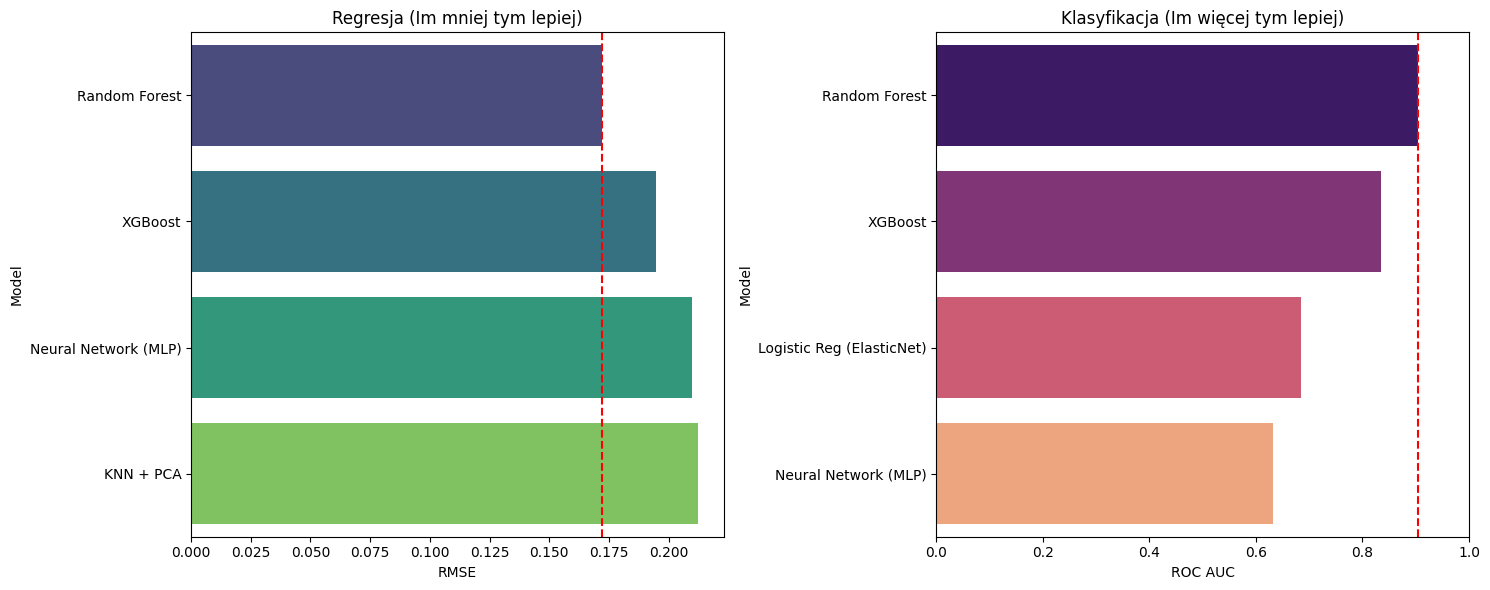

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='RMSE', y='Model', data=df_res_reg, ax=ax1, palette='viridis')
ax1.set_title('Regresja (Im mniej tym lepiej)')
ax1.axvline(winner_reg['RMSE'], color='r', linestyle='--')

sns.barplot(x='ROC AUC', y='Model', data=df_res_clf, ax=ax2, palette='magma')
ax2.set_title('Klasyfikacja (Im więcej tym lepiej)')
ax2.set_xlim(0, 1.0)
ax2.axvline(winner_clf['ROC AUC'], color='r', linestyle='--')

plt.tight_layout()
plt.show()

# aplikacja internetowa

In [ ]:
joblib.dump(rf, 'model_reg.joblib')
joblib.dump(rf_c, 'model_clf.joblib')

metrics = {
    'rmse': round(rmse_rf, 2),
    'accuracy': round(auc_rf, 4)
}
joblib.dump(metrics, 'metrics.joblib')

print(f"✅ Gotowe! Pliki zapisane w: {os.getcwd()}")

Zapisywanie modeli Random Forest...
✅ Gotowe! Pliki zapisane w: c:\Users\Szymon\Desktop\praca\projekt inżynierka\wybór modelu
Teraz przejdź do budowania aplikacji w folderze 'aplikacja_webowa'.
